In [ ]:
from google.colab import files
files.upload()

In [2]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:03<00:00, 6.98MB/s]



In [53]:
import os
import json
import re

from zipfile import ZipFile
import pandas as pd

In [34]:
!ls

'IMDB Dataset.csv'			 kaggle.json
 imdb-dataset-of-50k-movie-reviews.zip	 sample_data


In [35]:
# Unzip dataset file
with ZipFile('imdb-dataset-of-50k-movie-reviews.zip', 'r') as zipObj:
  zipObj.extractall()

In [36]:
!ls

'IMDB Dataset.csv'			 kaggle.json
 imdb-dataset-of-50k-movie-reviews.zip	 sample_data


In [37]:
data = pd.read_csv('IMDB Dataset.csv')

In [38]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [39]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [41]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [42]:
data.isnull().sum()

,0
review,0
sentiment,0


In [43]:
# changing categorical data into numeric values
data.replace({'sentiment': {'positive': 1, 'negative': 0}}, inplace=True)

/tmp/ipykernel_715/2339601191.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'sentiment': {'positive': 1, 'negative': 0}}, inplace=True)


In [44]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [48]:
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove special characters, punctuation and digits, keeping only alphabets
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase and strip whitespace
    text = text.lower().strip()
    return text

# Apply the cleaning function to the 'review' column
data['cleaned_review'] = data['review'].apply(clean_text)

# Display the first few rows to verify the cleaning process
data[['review', 'cleaned_review', 'sentiment']].head()

,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...,1


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instruction 2: Split the data
X_train_clean, X_test_clean, y_train_nb, y_test_nb = train_test_split(
    data['cleaned_review'],
    data['sentiment'],
    test_size=0.2,
    random_state=42
)

# Instruction 3: Initialize TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Instruction 4: Fit and transform
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

# Display shapes to verify
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")

X_train_tfidf shape: (40000, 5000)
X_test_tfidf shape: (10000, 5000)


In [50]:
from sklearn.naive_bayes import MultinomialNB

# Instruction 2: Instantiate the MultinomialNB model
nb_classifier = MultinomialNB()

# Instruction 3: Fit the model to the training data
nb_classifier.fit(X_train_tfidf, y_train_nb)

# Instruction 4: Verify training completion
print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


Naive Bayes Accuracy: 0.8486

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      4961
    Positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



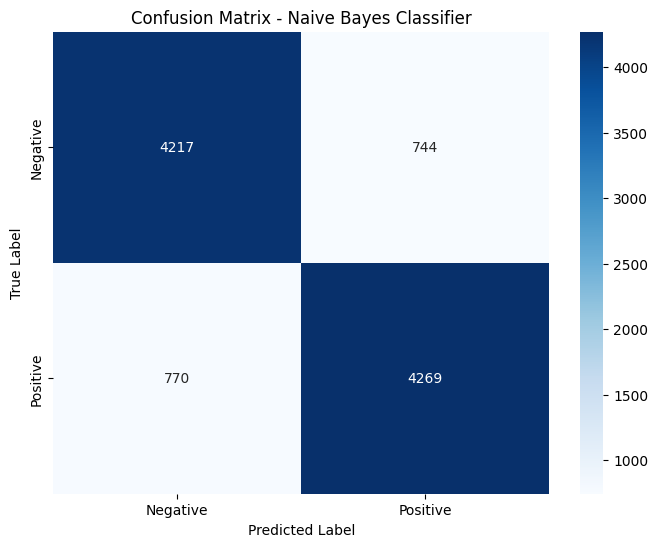

In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Instruction 2: Predict sentiment labels for the test set
y_pred_nb = nb_classifier.predict(X_test_tfidf)

# Instruction 3: Calculate accuracy
accuracy = accuracy_score(y_test_nb, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy:.4f}\n")

# Instruction 4: Print classification report
print("Classification Report:")
print(classification_report(y_test_nb, y_pred_nb, target_names=['Negative', 'Positive']))

# Instruction 5: Generate and display the confusion matrix
cm = confusion_matrix(y_test_nb, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes Classifier')
plt.show()

In [54]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

def all_metrics(y_true, y_pred):
    # Calculate Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Manual calculation of additional metrics
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    fdr = fp / (fp + tp) if (fp + tp) > 0 else 0

    # Sklearn metrics
    metrics_dict = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Specificity": specificity,
        "False Positive Rate": fpr,
        "False Negative Rate": fnr,
        "Negative Predictive Value": npv,
        "False Discovery Rate": fdr
    }

    return metrics_dict

print("Function 'all_metrics' has been defined.")

Function 'all_metrics' has been defined.


In [55]:
import pandas as pd

# Calculate metrics using the previously defined function
nb_metrics = all_metrics(y_test_nb, y_pred_nb)

# Convert the dictionary to a DataFrame for better visualization
metrics_df = pd.DataFrame(list(nb_metrics.items()), columns=['Metric', 'Score'])

# Display the DataFrame
print("Naive Bayes Classifier Performance Metrics:")
metrics_df

Naive Bayes Classifier Performance Metrics:


,Metric,Score
0,Accuracy,0.848600
1,Precision,0.851586
2,Recall,0.847192
3,F1-score,0.849383
4,MCC,0.697203
5,Specificity,0.850030
6,False Positive Rate,0.149970
7,False Negative Rate,0.152808
8,Negative Predictive Value,0.845599
9,False Discovery Rate,0.148414


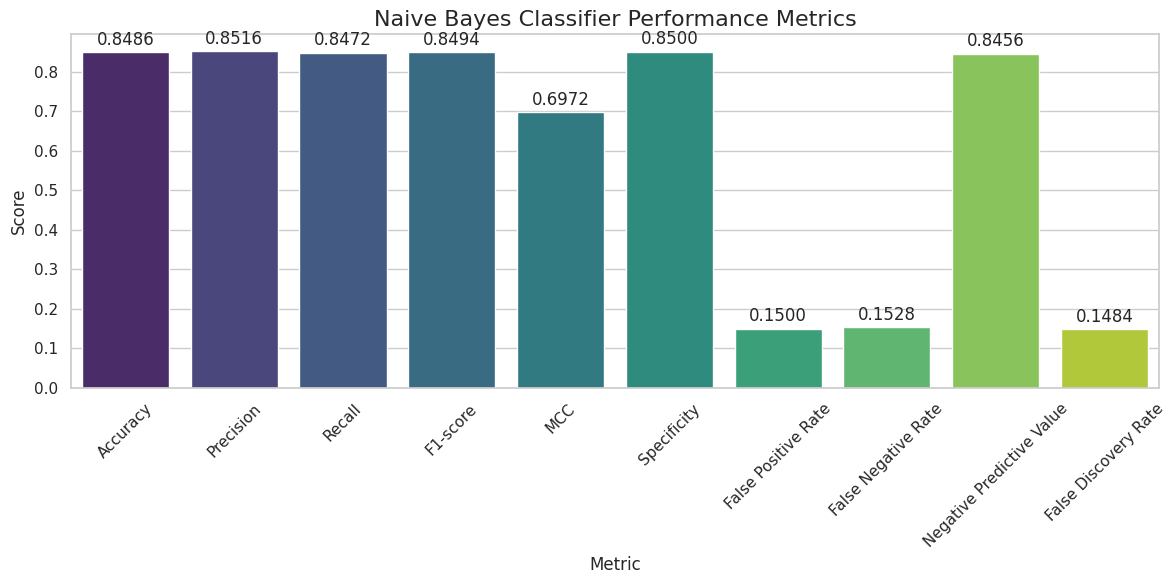

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create the bar plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Metric', y='Score', data=metrics_df, hue='Metric', palette='viridis', legend=False)

# Add labels and title
plt.title('Naive Bayes Classifier Performance Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)

# Rotate x-axis labels for better legibility
plt.xticks(rotation=45)

# Add score labels on top of bars for precision
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [52]:
def predict_sentiment(review):
    # Clean the input review
    cleaned_review = clean_text(review)
    # Vectorize the cleaned review using the trained TF-IDF vectorizer
    review_tfidf = tfidf.transform([cleaned_review])
    # Predict using the Naive Bayes classifier
    prediction = nb_classifier.predict(review_tfidf)
    # Convert numeric prediction back to label
    if prediction[0] == 1:
        sentiment = 'positive'
    else:
        sentiment = 'negative'
    return sentiment

# Test the updated function with previous examples
print(f"'This movie was fantastic. I loved it.' -> {predict_sentiment('This movie was fantastic. I loved it.')}")
print(f"'This movie was not that good' -> {predict_sentiment('This movie was not that good')}")

'This movie was fantastic. I loved it.' -> positive
'This movie was not that good' -> negative
